In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
from dotenv import load_dotenv
load_dotenv()
import tidy3d as td
from tidy3d import web
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import sys
import pandas as pd
from scipy.spatial import Delaunay

# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(r'H:\codes\tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

In [2]:
tidy3dAPI = os.environ["API_TIDY3D_KEY"]

In [3]:
a = 1
medium = td.Medium(permittivity=11.56)
run = True

In [4]:
lambdas =  1/np.array([0.15,0.85])

In [5]:
# Rod radius for the FST (Florescu-Steinhardt-Torquato) network. In scaled units (point density = 1).
# Typical range 0.04 - 0.10. Compare with cermet pillar radius of 0.189 from the individual-scatterer notebook.
rod_radius = 0.1

In [6]:
folder_path=rf"./Structures"
polarization = "TM"
add_field_monitor = True
project_name = fr"20260526 Transmission gyromorphs - SHU 100 x 15 Aaron Network {polarization} r_{rod_radius}{" Field" if add_field_monitor else ""}"
empty=False
runtime_ps = 20e-12
min_steps_per_lambda = 15
id0 = ""
add_ref = True
Lx, Ly = 100, 15


In [7]:
def get_scale_factor(data,N):
    xmin, xmax = data['x'].min(), data['x'].max()
    ymin, ymax = data['y'].min(), data['y'].max()
    Lx = xmax - xmin
    Ly = ymax - ymin
    A = Lx * Ly
    density = N / A
    scale = np.sqrt(density)
    print(f'  N = {N}')
    print(f'  x range: [{xmin:.6f}, {xmax:.6f}]  Lx = {Lx:.6f}')
    print(f'  y range: [{ymin:.6f}, {ymax:.6f}]  Ly = {Ly:.6f}')
    print(f'  Area A = {A:.6f}')
    print(f'  Density N/A = {density:.6f}')
    print(f'  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = {scale:.6f}')
    print(f'  (resulting box size: Lx*scale = {Lx*scale:.6f}, Ly*scale = {Ly*scale:.6f})')
    return {"scale": scale, "Lx": Lx, "Ly": Ly, "xmin": xmin, "xmax": xmax, "ymin": ymin, "ymax": ymax}

In [8]:
data = []
scales_data = []
for l,file in enumerate((os.listdir(folder_path))):
    print(Path(file).stem)
    df = pd.read_csv(os.path.join(folder_path, file))
    scales = get_scale_factor(df, N=len(df))
    df['x'] -=(scales["xmax"]+scales["xmin"])/2
    df['y'] -=(scales["ymax"]+scales["ymin"])/2
    print(f'  After centering:')
    print(df["x"].max(),df["x"].min())
    print(df["y"].max(),df["y"].min())
    data.append(df)
    scales_data.append(scales["scale"])


gyromorph24_2d_K120
  N = 14403
  x range: [-0.499922, 0.499396]  Lx = 0.999318
  y range: [-0.499946, 0.499881]  Ly = 0.999826
  Area A = 0.999144
  Density N/A = 14415.335770
  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = 120.063882
  (resulting box size: Lx*scale = 119.981960, Ly*scale = 120.043047)
  After centering:
0.49965883897293584 -0.49965883897293584
0.4999132321647317 -0.4999132321647317
SHU2D_N15700_K100.0
  N = 15700
  x range: [-0.007782, 1.009464]  Lx = 1.017246
  y range: [-0.012141, 1.015795]  Ly = 1.027936
  Area A = 1.045664
  Density N/A = 15014.376343
  Scale factor to get N/A = 1: multiply coords by sqrt(N/A) = 122.533164
  (resulting box size: Lx*scale = 124.646413, Ly*scale = 125.956292)
  After centering:
0.5086231719830051 -0.5086231719830051
0.5139681671499196 -0.5139681671499196


## FST (Florescu-Steinhardt-Torquato) network construction

The point pattern (gyromorph / SHU) is converted into a dielectric **network** instead of individual pillars:

1. Compute the Delaunay triangulation of the point set.
2. Each triangle contributes a centroid.
3. Centroids of every pair of edge-sharing triangles are joined with a dielectric rod.

This produces a trivalent network (3 rods per node) which is known to open large TE+TM photonic band gaps in hyperuniform / gyromorph systems. Reference: Florescu, Steinhardt & Torquato, PNAS 2009.

Rods are represented as `td.PolySlab` (a thin rectangle in the xy-plane extruded along z), and a small `td.Cylinder` cap is placed at each node so neighbouring rods join without mitering gaps.

In [9]:
def clip_segment_to_box(p1, p2, xmin, xmax, ymin, ymax):
    """Liang-Barsky clip of segment p1->p2 against an axis-aligned box. Returns (q1, q2) or None."""
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    p = [-dx, dx, -dy, dy]
    q = [x1 - xmin, xmax - x1, y1 - ymin, ymax - y1]
    u1, u2 = 0.0, 1.0
    for pi, qi in zip(p, q):
        if pi == 0:
            if qi < 0:
                return None
        else:
            t = qi / pi
            if pi < 0:
                if t > u2:
                    return None
                u1 = max(u1, t)
            else:
                if t < u1:
                    return None
                u2 = min(u2, t)
    if u1 > u2:
        return None
    return (np.array([x1 + u1*dx, y1 + u1*dy]),
            np.array([x1 + u2*dx, y1 + u2*dy]))


def build_fst_network(points_xy, rod_radius, Lx, Ly):
    """Build the FST centroid network from a 2D point set.

    Parameters
    ----------
    points_xy : (N, 2) ndarray
        Point pattern in real units (already scaled).
    rod_radius : float
        Half-thickness of the rods.
    Lx, Ly : float
        Simulation box size; rods/nodes outside |x|<=Lx/2, |y|<=Ly/2 are clipped.

    Returns
    -------
    list[td.Geometry]
        Rod polygons and node caps to be wrapped in a td.GeometryGroup.
    """
    tri = Delaunay(points_xy)
    # Centroid of every Delaunay triangle
    centroids = points_xy[tri.simplices].mean(axis=1)

    xmin, xmax = -Lx / 2.0, Lx / 2.0
    ymin, ymax = -Ly / 2.0, Ly / 2.0

    rod_geoms = []
    node_points = []

    seen_edges = set()
    for i, neighbours in enumerate(tri.neighbors):
        for j in neighbours:
            j = int(j)
            if j < 0:
                continue  # boundary edge of the triangulation
            key = (i, j) if i < j else (j, i)
            if key in seen_edges:
                continue
            seen_edges.add(key)

            c1 = centroids[i]
            c2 = centroids[j]

            clipped = clip_segment_to_box(c1, c2, xmin, xmax, ymin, ymax)
            if clipped is None:
                continue
            q1, q2 = clipped

            d = q2 - q1
            L = np.linalg.norm(d)
            if L < 1e-10:
                continue
            d /= L
            n = np.array([-d[1], d[0]])  # left-perpendicular unit vector

            verts = [
                tuple(q1 + rod_radius * n),
                tuple(q2 + rod_radius * n),
                tuple(q2 - rod_radius * n),
                tuple(q1 - rod_radius * n),
            ]
            rod_geoms.append(
                td.PolySlab(vertices=verts, slab_bounds=(-td.inf, td.inf), axis=2)
            )

            node_points.append(tuple(q1))
            node_points.append(tuple(q2))

    # Deduplicated caps so rod joints don't have miter gaps
    cap_geoms = []
    seen_caps = set()
    for x, y in node_points:
        key = (round(float(x), 8), round(float(y), 8))
        if key in seen_caps:
            continue
        seen_caps.add(key)
        cap_geoms.append(
            td.Cylinder(center=[float(x), float(y), 0.0], radius=rod_radius, length=td.inf)
        )

    return rod_geoms + cap_geoms


gyromorph24_2d_K120: 4602 rods, 3246 nodes


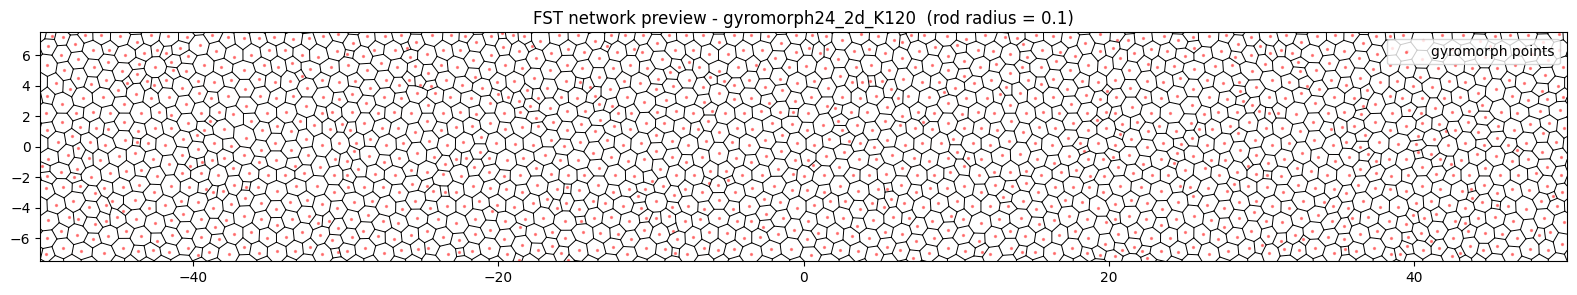

SHU2D_N15700_K100.0: 4844 rods, 3418 nodes


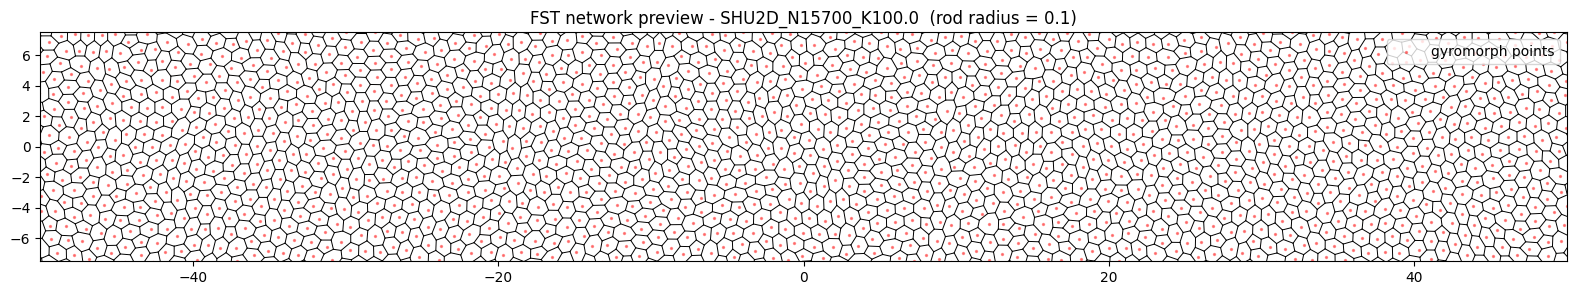

In [10]:
# Quick sanity-check plot of the network for each input structure before launching anything.
for k, df in enumerate(data):
    pts = np.column_stack([df['x'].values * scales_data[k],
                           df['y'].values * scales_data[k]])
    geoms = build_fst_network(pts, rod_radius=rod_radius, Lx=Lx, Ly=Ly)
    n_rods = sum(1 for g in geoms if isinstance(g, td.PolySlab))
    n_caps = sum(1 for g in geoms if isinstance(g, td.Cylinder))
    print(f"{Path(os.listdir(folder_path)[k]).stem}: {n_rods} rods, {n_caps} nodes")

    fig, ax = plt.subplots(1, 1, figsize=(16, 4), tight_layout=True)
    # Draw the network skeleton (centerlines) for a fast preview
    tri = Delaunay(pts)
    centroids = pts[tri.simplices].mean(axis=1)
    seen = set()
    for i, neigh in enumerate(tri.neighbors):
        for j in neigh:
            j = int(j)
            if j < 0:
                continue
            key = (i, j) if i < j else (j, i)
            if key in seen:
                continue
            seen.add(key)
            c1, c2 = centroids[i], centroids[j]
            clipped = clip_segment_to_box(c1, c2, -Lx/2, Lx/2, -Ly/2, Ly/2)
            if clipped is None:
                continue
            q1, q2 = clipped
            ax.plot([q1[0], q2[0]], [q1[1], q2[1]], 'k-', linewidth=0.7)
    ax.scatter(pts[:, 0], pts[:, 1], s=2, color='red', alpha=0.4, label='gyromorph points')
    ax.set_xlim(-Lx/2, Lx/2)
    ax.set_ylim(-Ly/2, Ly/2)
    ax.set_aspect('equal')
    ax.set_title(f"FST network preview - {Path(os.listdir(folder_path)[k]).stem}  (rod radius = {rod_radius})")
    ax.legend(loc='upper right')
    plt.show()


gyromorph24_2d_K120 Network Transmission 6.67 - 1.18
Configured successfully.


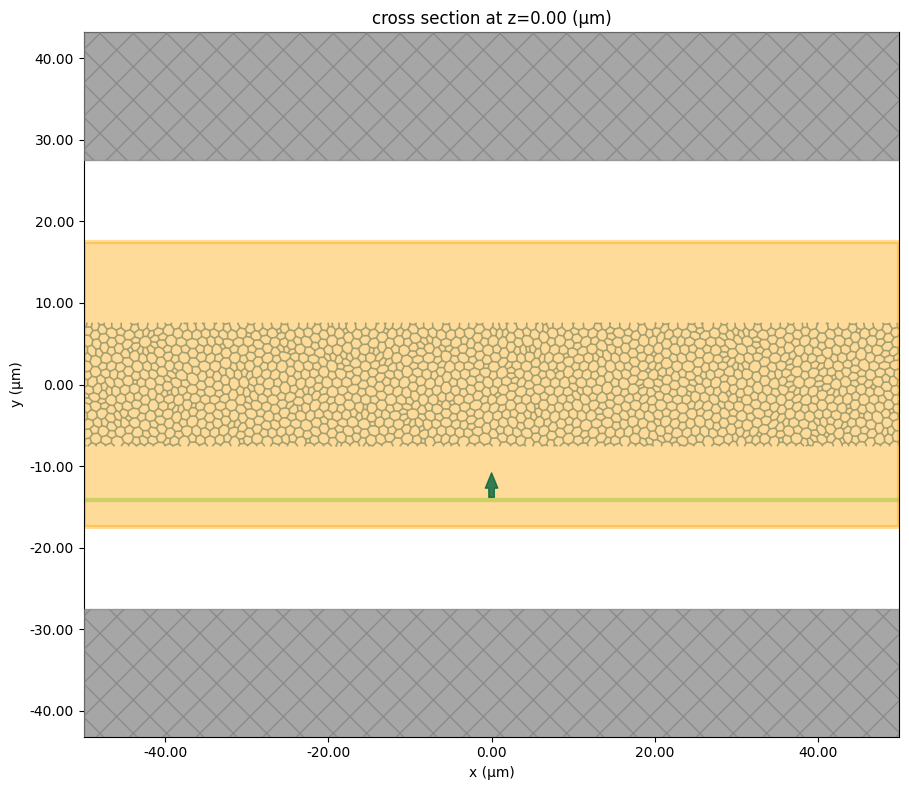

11:46:05 W. Europe Daylight Time Created task 'gyromorph24_2d_K120 Network      
                                 Transmission 6.67 - 1.18_0' with task_id       
                                 'fdve-1c410133-5235-4565-ba86-236049e0ee19' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=216510;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=178346;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\task]8;;\
                                 ]8;id=178346;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\Id]8;;\]8;id=216510;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\=]8;;\]8;id=887527;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\fdve]8;;\]8;id=216510;https://tidy3d.simulation.cloud/workbench?taskId=fdve-1c410133-5235-4565-ba86-236049e0ee19\-1c410133-5235-4565-ba86-236049e0ee19']8;;\.

                                 Task folder: ]8;id=442429;https://tidy3d.simulation.cloud/folders/folder-5fb31c73-1b76-4918-acfa-438c4b360d75\'20260526 Transmission gyromorphs ]8;;\
                                 ]8;id=442429;https://tidy3d.simulation.cloud/folders/folder-5fb31c73-1b76-4918-acfa-438c4b360d75\- SHU 100 x 15 Aaron Network TM r_0.1 Field']8;;\.

Output()

11:46:07 W. Europe Daylight Time Maximum FlexCredit cost: 1.223. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

Output()

12:12:17 W. Europe Daylight Time status = postprocess

12:14:34 W. Europe Daylight Time status = success

12:14:36 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=737666;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=965717;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\task]8;;\
                                 ]8;id=965717;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\Id]8;;\]8;id=737666;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\=]8;;\]8;id=996968;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\fdve]8;;\]8;id=737666;https://tidy3d.simulation.cloud/workbench?taskId=fdve-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8\-82d6b3ca-7299-4f2e-a28a-e4d68a3349a8']8;;\.

Folder '../../../data/20260526 Transmission gyromorphs - SHU 100 x 15 Aaron Network TM r_0.1 Field/gyromorph24_2d_K120' created successfully.
SHU2D_N15700_K100.0 Network Transmission 6.67 - 1.18
Configured successfully.


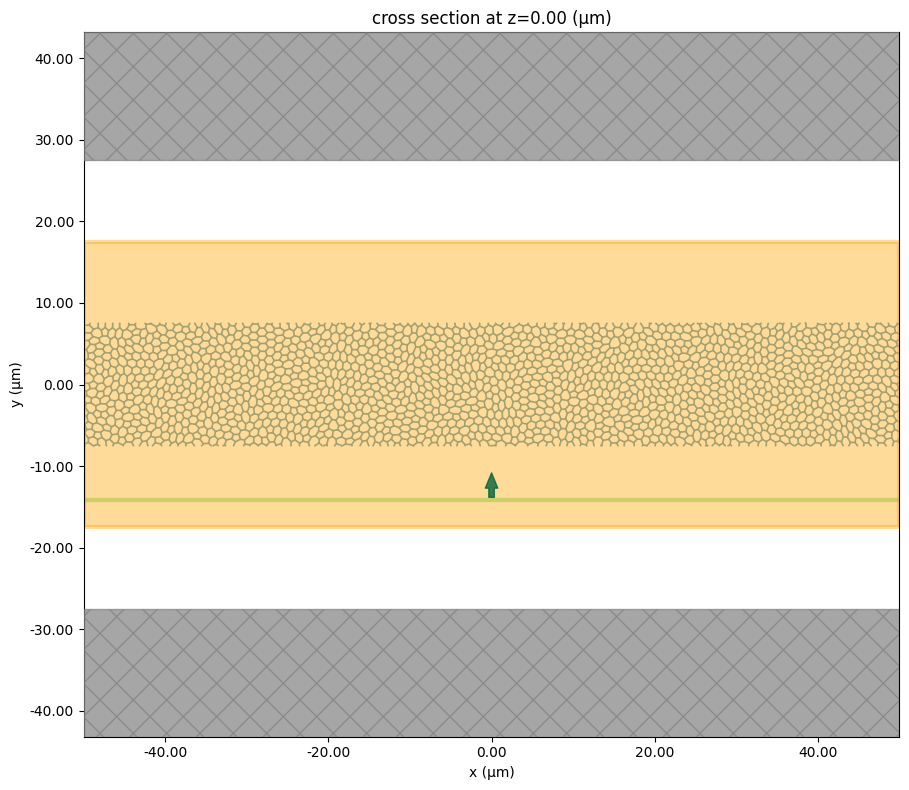

12:14:42 W. Europe Daylight Time Created task 'SHU2D_N15700_K100.0 Network      
                                 Transmission 6.67 - 1.18' with task_id         
                                 'fdve-92513142-ade5-4bf7-8790-b98d77e37a34' and
                                 task_type 'FDTD'.

                                 View task using web UI at                      
                                 ]8;id=751191;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=142636;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\task]8;;\
                                 ]8;id=142636;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\Id]8;;\]8;id=751191;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\=]8;;\]8;id=834126;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\fdve]8;;\]8;id=751191;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\-92513142-ade5-4bf7-8790-b98d77e37a34']8;;\.

                                 Task folder: ]8;id=755899;https://tidy3d.simulation.cloud/folders/folder-5fb31c73-1b76-4918-acfa-438c4b360d75\'20260526 Transmission gyromorphs ]8;;\
                                 ]8;id=755899;https://tidy3d.simulation.cloud/folders/folder-5fb31c73-1b76-4918-acfa-438c4b360d75\- SHU 100 x 15 Aaron Network TM r_0.1 Field']8;;\.

Output()

12:14:57 W. Europe Daylight Time Maximum FlexCredit cost: 1.223. Minimum cost   
                                 depends on task execution details. Use         
                                 'web.real_cost(task_id)' to get the billed     
                                 FlexCredit cost after a simulation run.

...

Output()

Output()

12:35:00 W. Europe Daylight Time status = postprocess

12:36:35 W. Europe Daylight Time View simulation result at                      
                                 ]8;id=92705;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=951974;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\task]8;;\
                                 ]8;id=951974;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\Id]8;;\]8;id=92705;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\=]8;;\]8;id=431128;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\fdve]8;;\]8;id=92705;https://tidy3d.simulation.cloud/workbench?taskId=fdve-92513142-ade5-4bf7-8790-b98d77e37a34\-92513142-ade5-4bf7-8790-b98d77e37a34']8;;\.

Folder '../../../data/20260526 Transmission gyromorphs - SHU 100 x 15 Aaron Network TM r_0.1 Field/SHU2D_N15700_K100.0' created successfully.


In [11]:

for k,item in enumerate(data):
        run_name = f"{Path(os.listdir(folder_path)[k]).stem} Network Transmission {lambdas[0]:.3g} - {lambdas[1]:.3g}"
        print(run_name)
        
        structure_1 = AM.loadAndRunStructure(key = tidy3dAPI
                    ,direction="z", lambda_range=lambdas,
                    box_size= 50,runtime_ps=runtime_ps,min_steps_per_lambda=min_steps_per_lambda,
                   scaling=1,shuoff_condtion=1e-20, verbose=True,
                   monitors=["flux"],
                   freqs=250, 
                   source="planewave", 
                   width=0.35, ref_only=True
                   )


        sim = structure_1.sim

        boundaries= td.BoundarySpec(
                y=td.Boundary(plus=td.Absorber(num_layers=200),minus=td.Absorber(num_layers=200)),
                x=td.Boundary.periodic(),
                z=td.Boundary.periodic(),
            )
        sim = sim.copy(update={'boundary_spec':boundaries})
        sim = sim.copy(update={'sources':[]})
        sim = sim.copy(update={'monitors':[]})


        sim = sim.copy(update={'size':[Lx,Ly+40,0]})

        source = td.PlaneWave(
                source_time = td.GaussianPulse(
                    freq0=structure_1.freq0,
                    fwidth=structure_1.freqw
                ),
                size= (td.inf,0,td.inf),
                center=(0,-(Ly)/2 - lambdas[0],0),
                direction='+',
                pol_angle=np.pi/2 if polarization == "TM" else 0,
                name='planewave',
                )

        sim = sim.copy(update={'sources':[source]})

      
        monitor_1 = td.FluxMonitor(
                center = (
                                0,-((Ly)/2+3),0
                                ),
                size = (
                   td.inf,0,td.inf
                    ),
                freqs = structure_1.monitor_freqs,
                name='flux2' )

        monitor_2 = td.FluxMonitor(
                center = (
                                0,(Ly)/2+3,0
                                ),
                size = (
                   td.inf,0,td.inf
                    ),
                freqs = structure_1.monitor_freqs,
                name='flux1' 
            )

        field_monitor = td.FieldMonitor(
                center = (0,0,0),
                size = (
                   Lx,Ly+20,0
                    ),
                freqs = structure_1.monitor_freqs,
                fields=["Ex", "Ey", "Ez"],
                name='field_monitor' 
            )
        
        monitors =[monitor_1,monitor_2]
        if add_field_monitor:
            monitors=[field_monitor]

        sim = sim.copy(update={'monitors':monitors})
        # Build the FST network from the (scaled) point pattern.
        pts = np.column_stack([data[k]['x'].values * scales_data[k],
                               data[k]['y'].values * scales_data[k]])
        network_geoms = build_fst_network(pts, rod_radius=rod_radius, Lx=Lx, Ly=Ly)
        network = td.Structure(geometry=td.GeometryGroup(geometries=network_geoms), medium=medium)


        if empty:
            sim = sim.copy(update={'structures':[],"grid_spec": td.GridSpec.uniform(dl=structure_1.dl)})
        else:
            sim = sim.copy(update={'structures':[network],"grid_spec": td.GridSpec.uniform(dl=structure_1.dl)})

        sim_name = run_name
        fig, ax = plt.subplots(1, tight_layout=True, figsize=(16, 8))
        sim.plot(z=0, ax=ax)
        plt.show()

        if run:
            if add_ref:
                 id0 =web.upload(sim.copy(update={'structures':[]}), folder_name=project_name,task_name=fr"{sim_name}_0", verbose=True)
                 web.start(task_id = id0)
                 web.monitor(task_id=id0,verbose=True)
                 add_ref = False

            id =web.upload(sim, folder_name=project_name,task_name=sim_name, verbose=True)
            web.start(task_id = id)
            web.monitor(task_id=id,verbose=True)
            ids = id0+ '\n' + id
            structure_folder =Path(os.listdir(folder_path)[k]).stem
            file_path = rf"../../../data/{project_name}/{structure_folder}/{sim_name}.txt"
            # Check if the folder exists
            if not os.path.exists( fr"../../../data/{project_name}/{structure_folder}"):
                os.makedirs(fr"../../../data/{project_name}/{structure_folder}",exist_ok=True)
                print(fr"Folder '../../../data/{project_name}/{structure_folder}' created successfully.")

            # Open file in write mode
            with open(file_path, "w") as f:
                # Write the string to the file
                f.write(ids)
        else:
            sim.plot_3d()
            raise TypeError("Program ends here")

